#Task 2: Exploratory Data Analysis (EDA) & Business Intelligence

PART 1: Setup & Data Loading

Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Upload & Load Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving netflix_cleaned.csv to netflix_cleaned.csv


In [4]:
df = pd.read_csv("netflix_cleaned.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


PART 2: Data Understanding

Step 3: Basic Info

In [5]:
df.shape


(8804, 12)

In [6]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8804 entries, 0 to 8803
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8804 non-null   object
 1   type          8804 non-null   object
 2   title         8804 non-null   object
 3   director      8804 non-null   object
 4   cast          8804 non-null   object
 5   country       8804 non-null   object
 6   date_added    8804 non-null   object
 7   release_year  8804 non-null   int64 
 8   rating        8804 non-null   object
 9   duration      8804 non-null   int64 
 10  listed_in     8804 non-null   object
 11  description   8804 non-null   object
dtypes: int64(2), object(10)
memory usage: 825.5+ KB


Step 4: Statistical Summary

In [8]:
df.describe()

,release_year,duration
count,8804.000000,8804.000000
mean,2014.180259,69.846888
std,8.820647,50.814828
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


PART 3: Data Validation

In [9]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [10]:
df.duplicated().sum()

np.int64(0)

PART 4: Feature Engineering

In [11]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

In [12]:
# Extract year and month from date_added
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [13]:
# Content age when added to Netflix
df['content_age_when_added'] = df['year_added'] - df['release_year']

In [14]:
# Number of genres per title
df['num_genres'] = df['listed_in'].apply(lambda x: len(str(x).split(',')))

In [15]:
# Primary (first) genre
df['primary_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())

In [16]:
# Binary: is it a Movie?
df['is_movie'] = (df['type'] == 'Movie').astype(int)

In [17]:
print(" Feature Engineering Done!")
df[['title', 'year_added', 'month_added', 'content_age_when_added',
    'num_genres', 'primary_genre', 'is_movie']].head()

 Feature Engineering Done!


,title,year_added,month_added,content_age_when_added,num_genres,primary_genre,is_movie
0,Dick Johnson Is Dead,2021,9,1,1,Documentaries,1
1,Blood & Water,2021,9,0,3,International TV Shows,0
2,Ganglands,2021,9,0,3,Crime TV Shows,0
3,Jailbirds New Orleans,2021,9,0,2,Docuseries,0
4,Kota Factory,2021,9,0,3,International TV Shows,0


 PART 5: Univariate Analysis

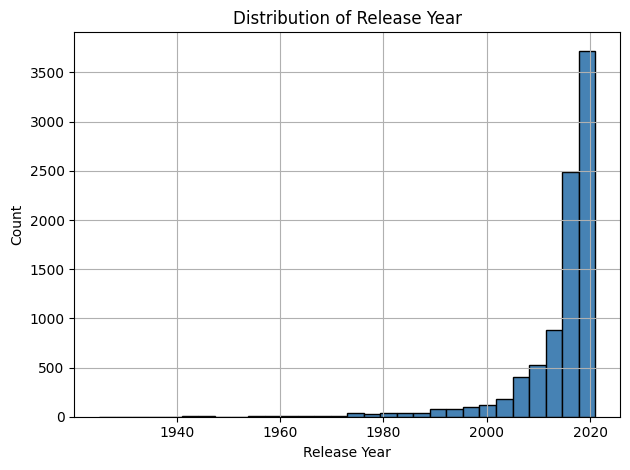

In [18]:
# --- Numerical ---
# Distribution of release_year
df['release_year'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



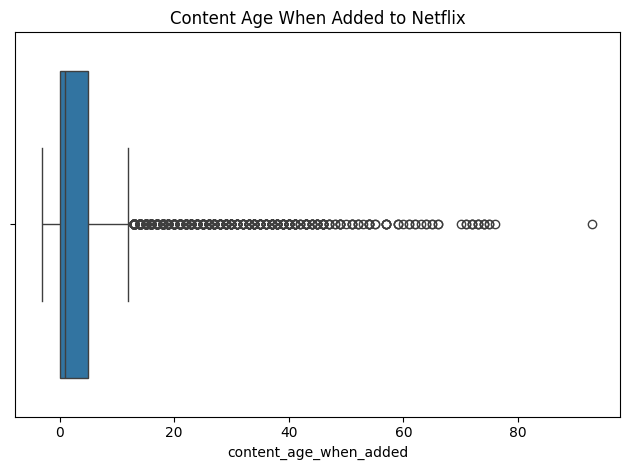

,count
type,
Movie,6128
TV Show,2676


In [19]:
# Boxplot of content_age_when_added
sns.boxplot(x=df['content_age_when_added'])
plt.title('Content Age When Added to Netflix')
plt.tight_layout()
plt.show()

# --- Categorical ---
# Content type count
df['type'].value_counts()

/tmp/ipykernel_6866/480119249.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['type'], palette='Set2')


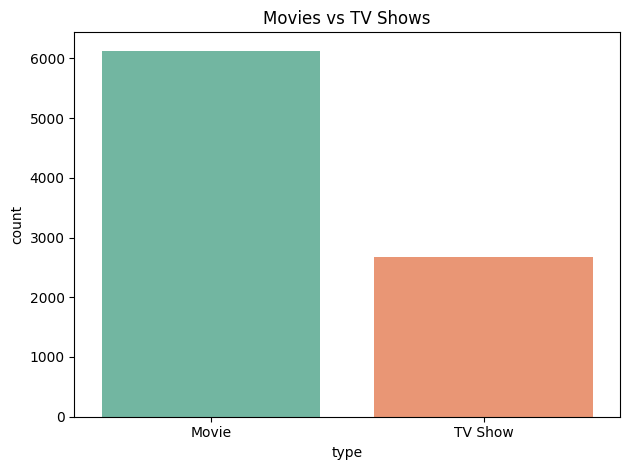

In [20]:
sns.countplot(x=df['type'], palette='Set2')
plt.title('Movies vs TV Shows')
plt.tight_layout()
plt.show()

In [21]:
# Top 10 ratings
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


/tmp/ipykernel_6866/533368950.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['rating'],


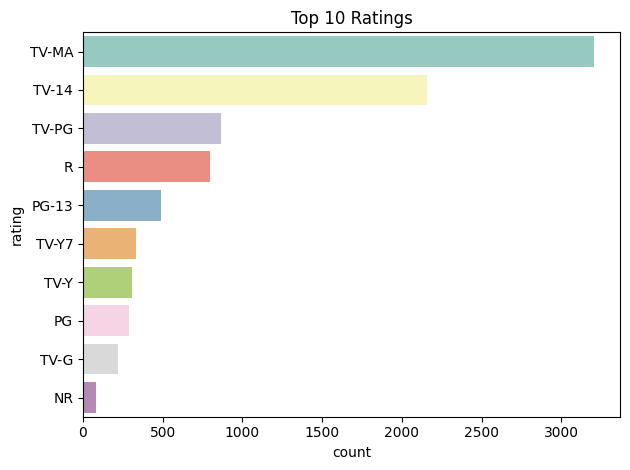

In [22]:
sns.countplot(y=df['rating'],
              order=df['rating'].value_counts().index[:10],
              palette='Set3')
plt.title('Top 10 Ratings')
plt.tight_layout()
plt.show()

PART 6: Country-Level Analysis

In [23]:
country_counts = df['country'].value_counts().sort_values(ascending=False)
print(country_counts.head(10))


country
United States     2815
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


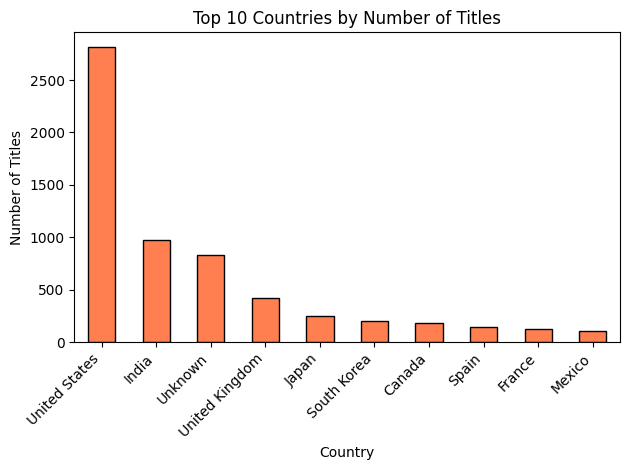

In [24]:
country_counts.head(10).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

PART 7: Multivariate Analysis

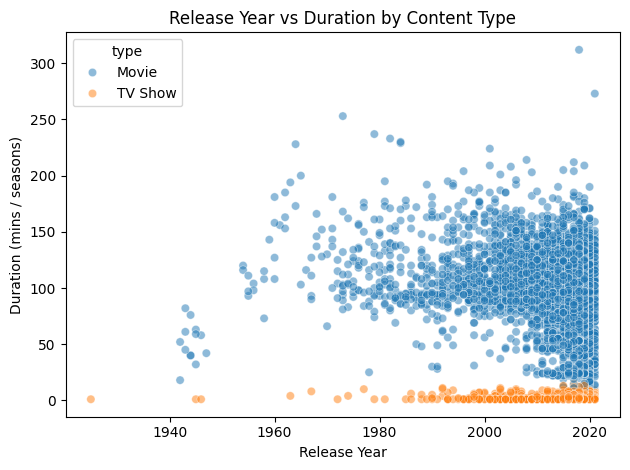

In [25]:
# Release Year vs Duration by Content Type
sns.scatterplot(x='release_year', y='duration', hue='type', data=df, alpha=0.5)
plt.title('Release Year vs Duration by Content Type')
plt.xlabel('Release Year')
plt.ylabel('Duration (mins / seasons)')
plt.tight_layout()
plt.show()

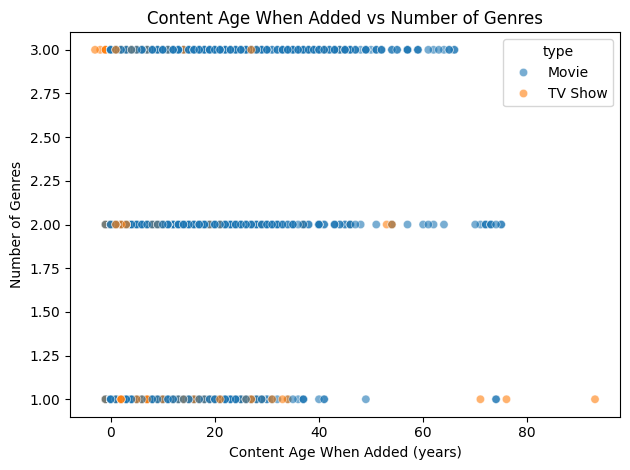

In [26]:
# Content Age When Added vs Number of Genres
sns.scatterplot(x='content_age_when_added', y='num_genres', hue='type', data=df, alpha=0.6)
plt.title('Content Age When Added vs Number of Genres')
plt.xlabel('Content Age When Added (years)')
plt.ylabel('Number of Genres')
plt.tight_layout()
plt.show()

PART 8: Correlation Analysis

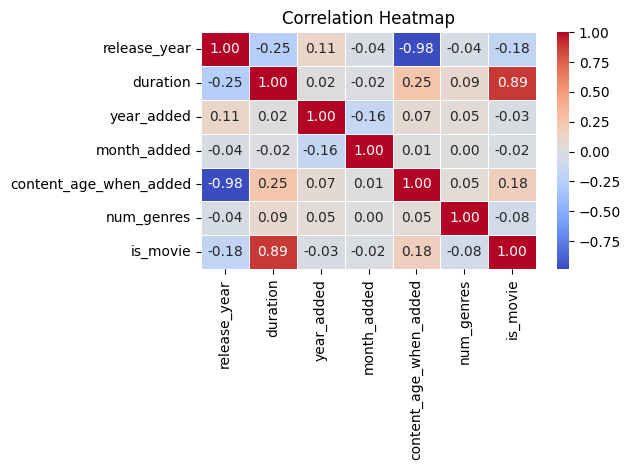

In [27]:
corr = df[['release_year', 'duration', 'year_added',
           'month_added', 'content_age_when_added',
           'num_genres', 'is_movie']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


PART 9: Pair Plot

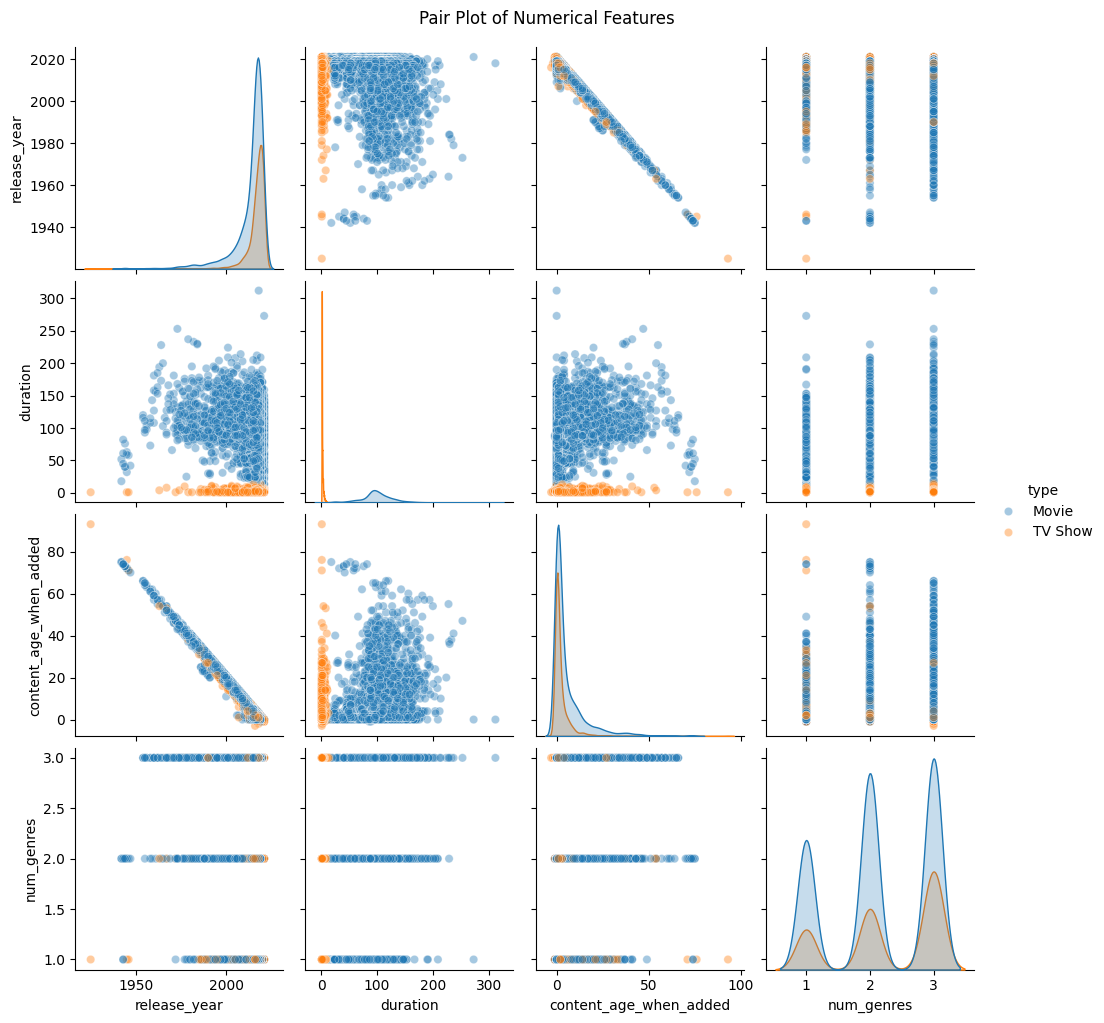

In [28]:
sns.pairplot(df[['release_year', 'duration', 'content_age_when_added',
                 'num_genres', 'type']],
             hue='type', plot_kws={'alpha': 0.4})
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

 PART 10: Time-Based Analysis

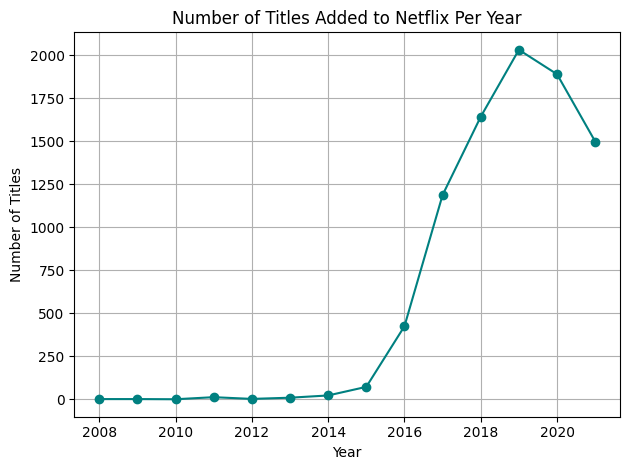

In [29]:
# Titles added per year
yearly = df.groupby('year_added')['title'].count()

yearly.plot(kind='line', marker='o', color='teal')
plt.title('Number of Titles Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.tight_layout()
plt.show()

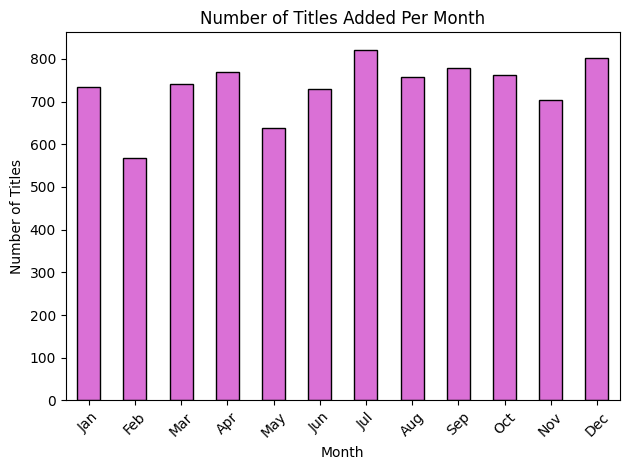

In [30]:
# Titles added per month
monthly = df.groupby('month_added')['title'].count()

monthly.plot(kind='bar', color='orchid', edgecolor='black')
plt.title('Number of Titles Added Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'],
           rotation=45)
plt.tight_layout()
plt.show()

 PART 11: Director-Level Analysis

In [31]:
# Equivalent of Customer Analysis for data

director_counts = df[df['director'] != 'Unknown'] \
                    .groupby('director')['title'].count() \
                    .sort_values(ascending=False)

print("Top 10 Directors by Number of Titles:")
print(director_counts.head(10))

Top 10 Directors by Number of Titles:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Youssef Chahine           12
Martin Scorsese           12
Steven Spielberg          11
Name: title, dtype: int64


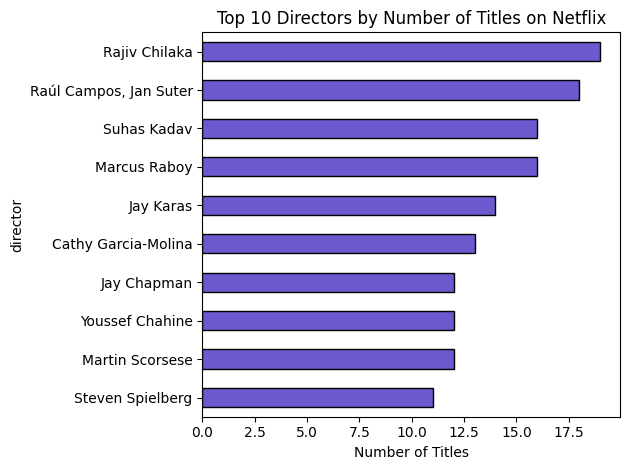

In [32]:
director_counts.head(10).plot(kind='barh', color='slateblue', edgecolor='black')
plt.title('Top 10 Directors by Number of Titles on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()